<a href="https://colab.research.google.com/github/eljaysmithdata/Data-Science-Bootcamp-2026/blob/main/Project-2/Housing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Project 2: Cleaning the Signal. Housing Price Regression Prediction - Final

AI Disclosure: ChatGPT was used to support concept clarification, wording refinement and visualization formatting. Final code execution and submission decisions were completed independently.


## Problem Definition

In this project, I used linear regression to predict home sale prices in Ames, Iowa from 2006 to 2010.

I approached this like a sound engineering problem:
- the true home value is the signal
- messy housing features are noise
- preprocessing, scaling, and regularization help clean the mix


The goal is not just to predict price, but to tune the model so the signal is clear, stable, and interpretable.



## Data/Collection Sources



### Data Overview

The data is available on AWS S3 at https://ddc-datascience.s3.amazonaws.com/Projects/Project.2-Housing/Data/Housing.Data.csv .




This dataset contains Ames, Iowa housing sales from 2006–2010.

The target variable is `SalePrice`.

In the sound analogy, `SalePrice` is the main vocal track — the signal we are trying to predict.

A data dictionary file is available at AWS S3 at [Housing Data Dictionary]( https://ddc-datascience.s3.amazonaws.com/Projects/Project.2-Housing/Housing%20-%20Data%20Documentation.pdf ).

The data dictionary describes a larger version of the dataset than the file provided for analysis. The working dataset contains 293 fewer rows than documented and is missing one documented variable, suggesting preprocessing or filtering occurred before release. Because no formal revision note accompanied the dataset, analysis was based on the observed dataset structure rather than assuming undocumented values.

### Imports

These libraries help with data inspection, visualization, model training, scaling, regularization, and evaluation.

In [1]:
# Core data tools
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Modeling
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Load the Data

First, I loaded the Ames housing dataset and previewed the data structure.

This is the raw recording before cleanup. Loading the data and viewing the data frame gives us a quick view of the data, including the number of rows and columns in the lower left.

In [2]:
# Load data
url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.2-Housing/Data/Housing.Data.csv"
df = pd.read_csv( url )

#Preview
df.head()


,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,905101070,20,RL,62.0,14299,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,7,2007,WD,Normal,115400
1,905101330,90,RL,72.0,10791,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,Shed,500,10,2006,WD,Normal,90000
2,903454090,50,RM,50.0,9000,Pave,NaN,Reg,Bnk,AllPub,...,0,NaN,NaN,NaN,0,12,2007,WD,Normal,141000
3,533244030,60,FV,68.0,7379,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,254000
4,909252020,70,RL,60.0,7200,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,4,2009,WD,Normal,155000


### Create a new copy - #1

In [3]:
# make backup
df_bak01 = df.copy()
df_bak01

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,905101070,20,RL,62.0,14299,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,7,2007,WD,Normal,115400
1,905101330,90,RL,72.0,10791,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,Shed,500,10,2006,WD,Normal,90000
2,903454090,50,RM,50.0,9000,Pave,NaN,Reg,Bnk,AllPub,...,0,NaN,NaN,NaN,0,12,2007,WD,Normal,141000
3,533244030,60,FV,68.0,7379,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,254000
4,909252020,70,RL,60.0,7200,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,4,2009,WD,Normal,155000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2632,903231070,50,RM,52.0,6240,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,Shed,400,9,2006,WD,Normal,114500
2633,906201021,80,RL,74.0,10778,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2009,WD,Normal,162000
2634,533253070,120,RL,61.0,3782,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2009,WD,Normal,211500
2635,527376100,20,RL,78.0,10140,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,8,2009,WD,Normal,165000


In [4]:
# restore from backup
df = df_bak01.copy()
df

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,905101070,20,RL,62.0,14299,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,7,2007,WD,Normal,115400
1,905101330,90,RL,72.0,10791,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,Shed,500,10,2006,WD,Normal,90000
2,903454090,50,RM,50.0,9000,Pave,NaN,Reg,Bnk,AllPub,...,0,NaN,NaN,NaN,0,12,2007,WD,Normal,141000
3,533244030,60,FV,68.0,7379,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,254000
4,909252020,70,RL,60.0,7200,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,4,2009,WD,Normal,155000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2632,903231070,50,RM,52.0,6240,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,Shed,400,9,2006,WD,Normal,114500
2633,906201021,80,RL,74.0,10778,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2009,WD,Normal,162000
2634,533253070,120,RL,61.0,3782,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2009,WD,Normal,211500
2635,527376100,20,RL,78.0,10140,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,8,2009,WD,Normal,165000


## Initial Inspection

Before modeling, I need to understand the shape, columns, missing values, and target variable.

This is like checking the recording session before mixing:
- How many tracks do I have?
- Are any tracks missing audio?
- What does the main signal look like?

Before fitting a regression model, I need to inspect:
- how many rows and columns I have
- which variables are numeric or categorical
- where missing values appear
- whether the data structure supports the assumptions of linear regression

In [5]:
df.head()

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,905101070,20,RL,62.0,14299,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,7,2007,WD,Normal,115400
1,905101330,90,RL,72.0,10791,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,Shed,500,10,2006,WD,Normal,90000
2,903454090,50,RM,50.0,9000,Pave,NaN,Reg,Bnk,AllPub,...,0,NaN,NaN,NaN,0,12,2007,WD,Normal,141000
3,533244030,60,FV,68.0,7379,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,254000
4,909252020,70,RL,60.0,7200,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,4,2009,WD,Normal,155000


In [6]:
# Dataset shape
df.shape

(2637, 81)

In [7]:
#Dataset structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2637 entries, 0 to 2636
Data columns (total 81 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PID              2637 non-null   int64  
 1   MS SubClass      2637 non-null   int64  
 2   MS Zoning        2637 non-null   object 
 3   Lot Frontage     2188 non-null   float64
 4   Lot Area         2637 non-null   int64  
 5   Street           2637 non-null   object 
 6   Alley            180 non-null    object 
 7   Lot Shape        2637 non-null   object 
 8   Land Contour     2637 non-null   object 
 9   Utilities        2637 non-null   object 
 10  Lot Config       2637 non-null   object 
 11  Land Slope       2637 non-null   object 
 12  Neighborhood     2637 non-null   object 
 13  Condition 1      2637 non-null   object 
 14  Condition 2      2637 non-null   object 
 15  Bldg Type        2637 non-null   object 
 16  House Style      2637 non-null   object 
 17  Overall Qual  

In [8]:
df.describe(include= "all").transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PID,2637.0,NaN,NaN,NaN,714130147.70383,188752674.750322,526301100.0,528477010.0,535453040.0,907187010.0,1007100110.0
MS SubClass,2637.0,NaN,NaN,NaN,57.349261,42.499091,20.0,20.0,50.0,70.0,190.0
MS Zoning,2637,7,RL,2043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Lot Frontage,2188.0,NaN,NaN,NaN,69.166819,23.356779,21.0,58.0,68.0,80.0,313.0
Lot Area,2637.0,NaN,NaN,NaN,10044.694729,6742.549521,1300.0,7436.0,9450.0,11526.0,164660.0
...,...,...,...,...,...,...,...,...,...,...,...
Mo Sold,2637.0,NaN,NaN,NaN,6.243838,2.722093,1.0,4.0,6.0,8.0,12.0
Yr Sold,2637.0,NaN,NaN,NaN,2007.795601,1.306403,2006.0,2007.0,2008.0,2009.0,2010.0
Sale Type,2637,10,WD,2286,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sale Condition,2637,6,Normal,2166,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Target definition

Quick first look at our target, which is SalePrice, and its distribution.

In [9]:
target = "SalePrice"

In [10]:
df[target].describe()

,SalePrice
count,2637.000000
mean,179986.230186
std,78309.251522
min,12789.000000
25%,129500.000000
50%,160000.000000
75%,213000.000000
max,745000.000000


In [11]:
df["SalePrice"].value_counts( dropna= False)

,count
SalePrice,
140000,31
135000,30
130000,28
155000,24
160000,22
...,...
160200,1
174190,1
415298,1


In [12]:
df["SalePrice"].value_counts( normalize=True, dropna= False).mul(100)

,proportion
SalePrice,
140000,1.175578
135000,1.137656
130000,1.061813
155000,0.910125
160000,0.834281
...,...
160200,0.037922
174190,0.037922
415298,0.037922


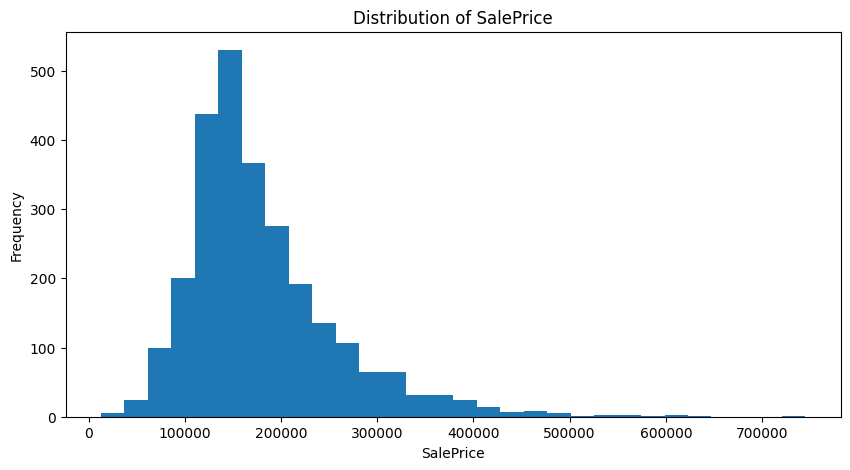

In [13]:
plt.figure(figsize=(10, 5))
plt.hist(df[target], bins=30)
plt.xlabel("SalePrice")
plt.ylabel("Frequency")
plt.title("Distribution of SalePrice")
plt.show()

In [14]:
numeric_df = df.select_dtypes(include=["int64", "float64"])
numeric_df.corr()["SalePrice"].sort_values(ascending=False)

,SalePrice
SalePrice,1.000000
Overall Qual,0.805016
Gr Liv Area,0.705482
Garage Cars,0.647223
Garage Area,0.633900
Total Bsmt SF,0.628669
1st Flr SF,0.618247
Year Built,0.562777
Full Bath,0.542386
Year Remod/Add,0.539932


## Data Cleaning

The target variable is **SalePrice**.

The target does not need to be perfectly normally distributed for linear regression, but extreme skew or outliers can affect model performance.

### Feature Selection (Simple - 1st Pass)

Use strong numberic features first

In the sound analogy, this is like choosing which tracks belong in the mix before adjusting levels.

In [15]:
# First, we selct numeric only features
numeric_df = df.select_dtypes(include=["int64", "float64"])

# Second, we check correlation in order to choose strongest usable variables
numeric_df.corr()["SalePrice"].sort_values(ascending=False)

,SalePrice
SalePrice,1.000000
Overall Qual,0.805016
Gr Liv Area,0.705482
Garage Cars,0.647223
Garage Area,0.633900
Total Bsmt SF,0.628669
1st Flr SF,0.618247
Year Built,0.562777
Full Bath,0.542386
Year Remod/Add,0.539932


This feature selection is justified by:

strong correlation + domain relevance + interpretability

That is enough for first pass.

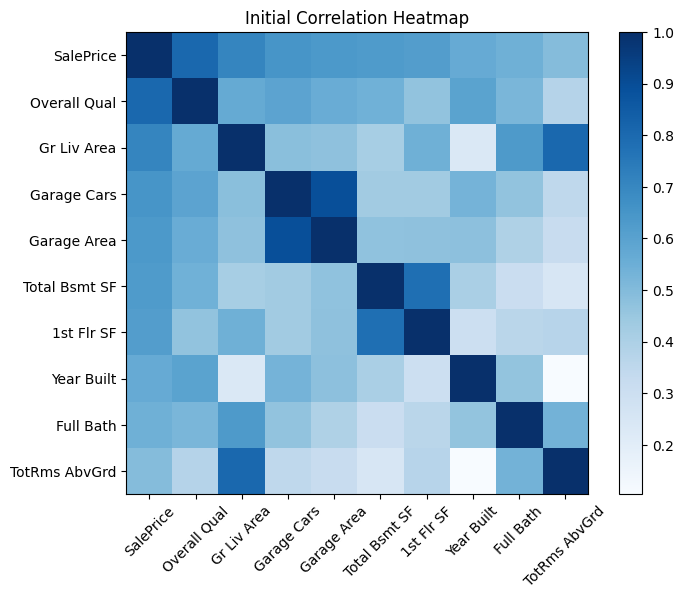

In [16]:
# Select strongest numerical features plus target
selected_features = [
    "SalePrice",
    "Overall Qual",
    "Gr Liv Area",
    "Garage Cars",
    "Garage Area",
    "Total Bsmt SF",
    "1st Flr SF",
    "Year Built",
    "Full Bath",
    "TotRms AbvGrd"
]

# Correlation matrix
corr = df[selected_features].corr()

# Plot heatmap
plt.figure(figsize=(8,6))
plt.imshow(corr, cmap="Blues")

# Labels
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

# Color scale
plt.colorbar()

# Title
plt.title("Initial Correlation Heatmap")

plt.show()

In [17]:
df[selected_features].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2637 entries, 0 to 2636
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SalePrice      2637 non-null   int64  
 1   Overall Qual   2637 non-null   int64  
 2   Gr Liv Area    2637 non-null   int64  
 3   Garage Cars    2636 non-null   float64
 4   Garage Area    2636 non-null   float64
 5   Total Bsmt SF  2636 non-null   float64
 6   1st Flr SF     2637 non-null   int64  
 7   Year Built     2637 non-null   int64  
 8   Full Bath      2637 non-null   int64  
 9   TotRms AbvGrd  2637 non-null   int64  
dtypes: float64(3), int64(7)
memory usage: 206.1 KB


In [18]:
# Create variable for selected features

features = [
    "Overall Qual",
    "Gr Liv Area",
    "Garage Cars",
    "Garage Area",
    "Total Bsmt SF",
    "1st Flr SF",
    "Year Built",
    "Full Bath",
    "TotRms AbvGrd"
]

target = "SalePrice"

df_model = df[features + [target]].copy()

print(df_model.shape)
df_model.head(20)

(2637, 10)


,Overall Qual,Gr Liv Area,Garage Cars,Garage Area,Total Bsmt SF,1st Flr SF,Year Built,Full Bath,TotRms AbvGrd,SalePrice
0,4,1005,2.0,440.0,1005.0,1005,1964,1,5,115400
1,4,1296,2.0,516.0,0.0,1296,1967,2,6,90000
2,6,1375,1.0,544.0,780.0,780,1937,1,6,141000
3,8,1848,2.0,592.0,975.0,975,2000,2,7,254000
4,7,1135,2.0,576.0,560.0,575,1936,1,6,155000
5,5,912,1.0,336.0,912.0,912,1967,1,5,125000
6,7,1232,2.0,632.0,1232.0,1232,2007,2,6,194500
7,6,1674,2.0,396.0,1163.0,1163,1918,2,8,185000
8,7,1865,3.0,839.0,992.0,992,2000,2,7,235000
9,6,1616,1.0,216.0,1149.0,1149,1926,2,5,152000


### Unique Identifiers

I selected a focused group of numeric features that are strongly related to housing price.

Because I manually selected these variables, unique identifiers were automatically excluded from the model.

This helps prevent meaningless row-level identifiers from entering regression, since identifiers do not carry predictive housing signal.

### Missing values

Missing values are like dead air in an audio channel.

If too much information is missing, the signal becomes unreliable.  
This step helps identify which features may need cleaning, imputation, or removal before modeling.

In [19]:
# Missing values from raw dataset is unmanageble
df.isnull().sum().sort_values(ascending=False)

,0
Pool QC,2626
Misc Feature,2541
Alley,2457
Fence,2109
Mas Vnr Type,1607
...,...
Mo Sold,0
Yr Sold,0
Sale Type,0
Sale Condition,0


In [20]:
# Missing values after a simple correlation-basic and numeric-only feature selection are much easier to manage
df_model.isnull().sum().sort_values(ascending=False)

,0
Garage Area,1
Garage Cars,1
Total Bsmt SF,1
Overall Qual,0
Gr Liv Area,0
1st Flr SF,0
Year Built,0
Full Bath,0
TotRms AbvGrd,0
SalePrice,0


In [21]:
# Impute missing values with median value
df_model = df_model.fillna(df_model.median())
df_model.isnull().sum().sort_values(ascending=False)

,0
Overall Qual,0
Gr Liv Area,0
Garage Cars,0
Garage Area,0
Total Bsmt SF,0
1st Flr SF,0
Year Built,0
Full Bath,0
TotRms AbvGrd,0
SalePrice,0


## Exploratory Data Analysis

### Linear Regression Assumption

Linear regression works best when several assumptions are reasonably satisfied:

- predictors should relate linearly to sale price
- residuals should appear random
- error variance should remain fairly consistent
- predictors should not be excessively redundant

In sound engineering terms:
- each channel should contribute in a usable, predictable way
- leftover noise should not form a hidden pattern
- volume should stay reasonably stable across the mix
- channels should not duplicate each other too heavily

This notebook begins checking those assumptions through:
- feature inspection
- correlation review
- scaling
- regularization
- residual analysis

####  Correlation

In the sound analogy, this is where I ask:
Which channels are actually carrying useful sound?

Correlation does not prove everything, but it helps identify numeric features with stronger linear relationships to sale price.

In [22]:
corr = df_model.corr(numeric_only=True)
corr["SalePrice"].sort_values(ascending=False).head(15)

,SalePrice
SalePrice,1.000000
Overall Qual,0.805016
Gr Liv Area,0.705482
Garage Cars,0.647151
Garage Area,0.633877
Total Bsmt SF,0.628533
1st Flr SF,0.618247
Year Built,0.562777
Full Bath,0.542386
TotRms AbvGrd,0.493853


#### Check linear relationships

These scatterplots help check whether important predictors have a roughly linear relationship with sale price.

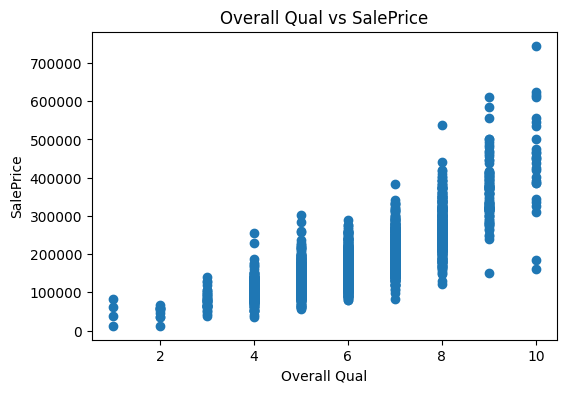

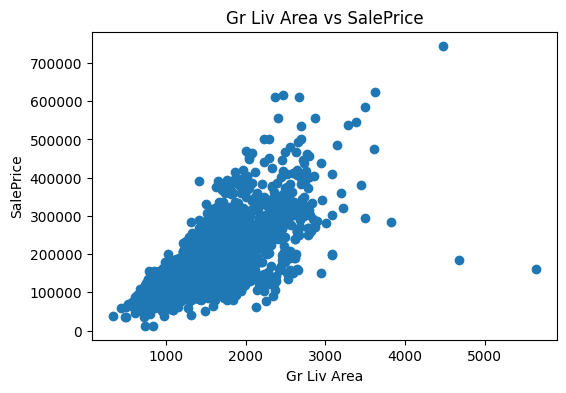

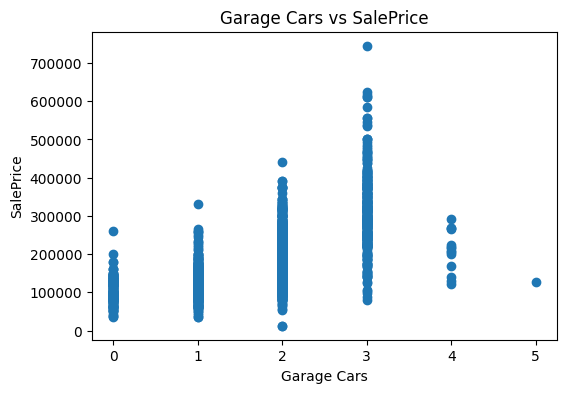

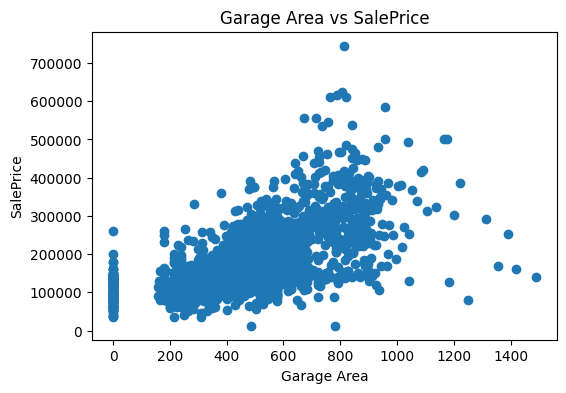

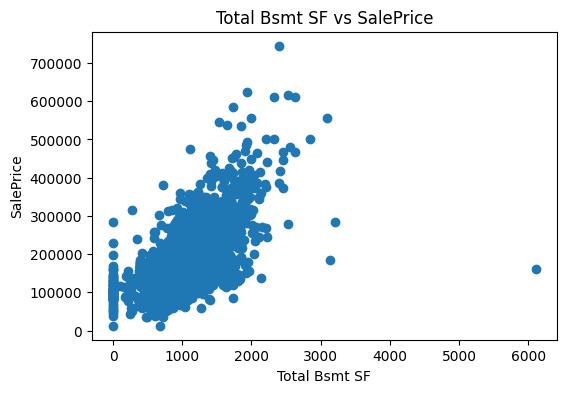

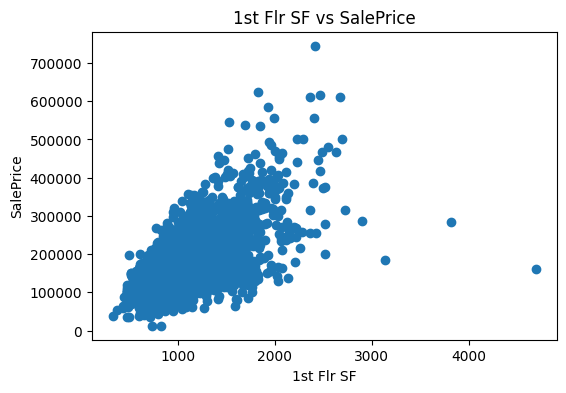

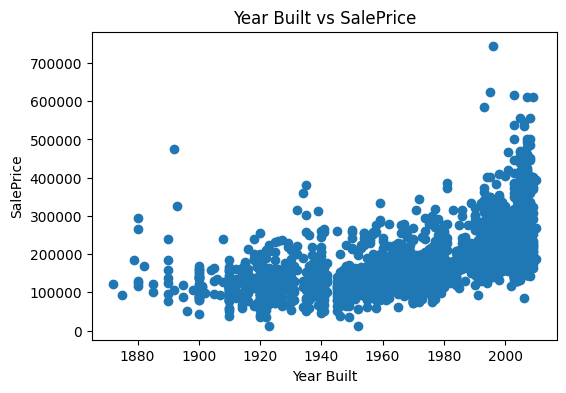

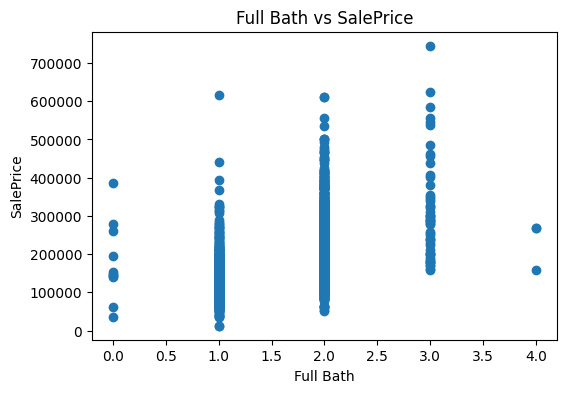

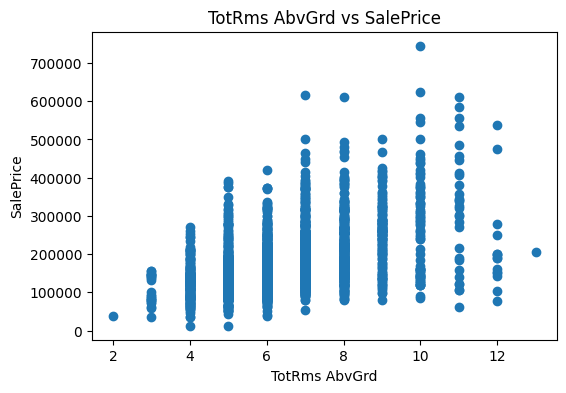

In [23]:
features = features = [
    "Overall Qual",
    "Gr Liv Area",
    "Garage Cars",
    "Garage Area",
    "Total Bsmt SF",
    "1st Flr SF",
    "Year Built",
    "Full Bath",
    "TotRms AbvGrd"
]

target = "SalePrice"

df_model = df[features + [target]].copy()

df_model.head()

for feature in features:
    plt.figure(figsize=(6,4))
    plt.scatter(df[feature], df["SalePrice"])
    plt.xlabel(feature)
    plt.ylabel("SalePrice")
    plt.title(f"{feature} vs SalePrice")
    plt.show()


These scatterplots show how several important housing features relate to SalePrice.

Overall Qual shows the strongest structured upward pattern, suggesting that higher construction quality is consistently associated with higher sale prices.

Gr Liv Area, Total Bsmt SF, and 1st Flr SF also show clear positive trends, although the spread becomes wider at larger values.

Garage Cars shows a stepped pattern because it is a discrete variable, but higher garage capacity still generally corresponds to higher sale prices.

In sound engineering terms, these predictors act like strong channels feeding the mix:
each one carries useful signal, although some channels become noisier at higher values.

The widening spread at larger values suggests that price variation increases for larger homes, which may indicate mild heteroscedasticity and should be checked again later through residual analysis.

#### Check redundancy/multicollinearity

Linear regression does not like predictors that overlap too heavily.

In sound engineering terms, this is like having multiple microphones picking up nearly the same signal.  
The mix becomes harder to interpret, and coefficient values can become unstable.

high correlation = loud channel
low correlation = faint channel
too many correlated predictors = overlapping microphones

This heatmap helps reveal where predictors may be too redundant.

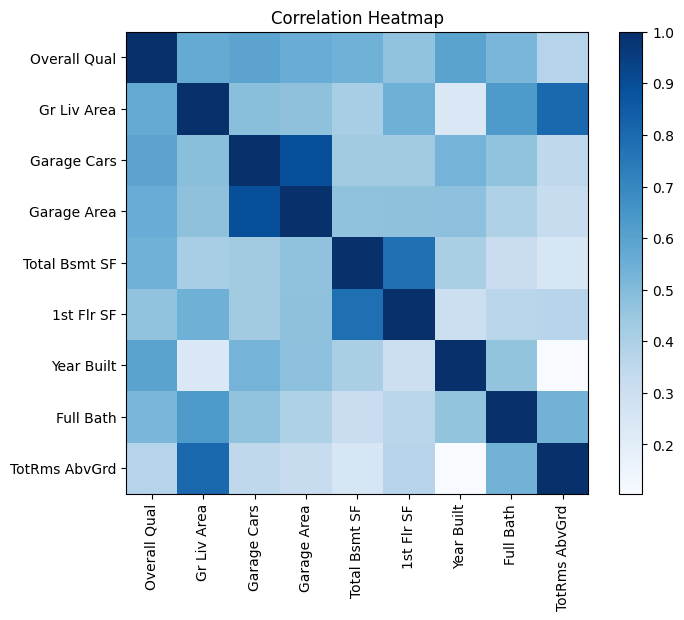

In [24]:
features = [
    "Overall Qual",
    "Gr Liv Area",
    "Garage Cars",
    "Garage Area",
    "Total Bsmt SF",
    "1st Flr SF",
    "Year Built",
    "Full Bath",
    "TotRms AbvGrd"
]

target = "SalePrice"

df_model = df[features + [target]].copy()

df_model.head()
corr_subset = df[features].corr()

plt.figure(figsize=(8,6))
plt.imshow(corr_subset, cmap="Blues", interpolation="none")
plt.colorbar()
plt.xticks(range(len(corr_subset.columns)), corr_subset.columns, rotation=90)
plt.yticks(range(len(corr_subset.columns)), corr_subset.columns)
plt.title("Correlation Heatmap")
plt.show()

Before regression, this is your listening board

The heatmap is where you first hear:


1.   Which tracks are loudest
2.   Which tracks overlap
3.   Which tracks deserve the mix



This heatmap helps identify whether important predictors overlap too heavily.

In linear regression, high multicollinearity can make coefficients unstable because multiple predictors may be describing nearly the same housing characteristic.

The strongest overlap appears between:

- Garage Cars and Garage Area  
- Total Bsmt SF and 1st Flr SF  

In sound engineering terms, this is like two microphones picking up nearly the same instrument. The model still hears the signal, but it becomes harder to decide which channel deserves credit.

Because of this, regularization becomes especially useful later in the notebook.

## Data Processing

### Create a new copy - #2

In [25]:
# Create back up #2
df_clean = df_model.copy()
df_clean

,Overall Qual,Gr Liv Area,Garage Cars,Garage Area,Total Bsmt SF,1st Flr SF,Year Built,Full Bath,TotRms AbvGrd,SalePrice
0,4,1005,2.0,440.0,1005.0,1005,1964,1,5,115400
1,4,1296,2.0,516.0,0.0,1296,1967,2,6,90000
2,6,1375,1.0,544.0,780.0,780,1937,1,6,141000
3,8,1848,2.0,592.0,975.0,975,2000,2,7,254000
4,7,1135,2.0,576.0,560.0,575,1936,1,6,155000
...,...,...,...,...,...,...,...,...,...,...
2632,6,1176,2.0,528.0,816.0,816,1934,1,6,114500
2633,7,1061,2.0,462.0,1054.0,1061,1990,1,4,162000
2634,8,1226,2.0,484.0,1226.0,1226,1981,1,4,211500
2635,6,1350,2.0,478.0,1064.0,1350,1974,2,7,165000


In [26]:
# Establish variables for both target and selected features

features = df_clean.drop('SalePrice', axis=1)
target = df_clean['SalePrice']

In [27]:
target

,SalePrice
0,115400
1,90000
2,141000
3,254000
4,155000
...,...
2632,114500
2633,162000
2634,211500
2635,165000


In [28]:
selected_features

['SalePrice',
 'Overall Qual',
 'Gr Liv Area',
 'Garage Cars',
 'Garage Area',
 'Total Bsmt SF',
 '1st Flr SF',
 'Year Built',
 'Full Bath',
 'TotRms AbvGrd']

In [29]:
# Fill missing numeric values with median
selected_features = features.fillna(features.median())

In [30]:
selected_features.isna().sum().sum()

np.int64(0)

### Linear Regression

#### Train/Test Split #1

In [31]:
features_train_simple, features_test_simple, target_train, target_test = train_test_split(
    selected_features,
    target,
    test_size=0.2,
    random_state=42
)

In [32]:
features_train_simple.shape, features_test_simple.shape

((2109, 9), (528, 9))

In [33]:
model1 = LinearRegression()


In [34]:
model1.fit(features_train_simple, target_train)

LinearRegression()

In [35]:
predictions = model1.predict(features_test_simple)

In [36]:
print("MAE:", mean_absolute_error(target_test, predictions))
print("R2:", r2_score(target_test, predictions))

MAE: 23429.041444636263
R2: 0.8174112795884563


##### RMSPE #1
RMSPE shows the model’s average percentage error relative to actual sale price. Lower RMSPE means predictions stay closer to the true housing signal.

In [37]:
# Creating a function that will calculate the RMSPE
def rmspe(y_true, y_pred):
    percentage_error = (y_true - y_pred) / y_true
    return np.sqrt(np.mean(percentage_error ** 2))

In [38]:
simple_linear_rmspe = rmspe(target_test, predictions)

print(f"RMSPE: {simple_linear_rmspe * 100:.2f}%")

RMSPE: 20.94%


#### Feature Selection (Refined - 2nd Pass)

Here we are selecting "Overall Qual" because it is the strongest signal and captures the overall contstruction quality. 2nd feature selected is Gr Liv Area (0.705), which is the total above-ground living space and is a very intuitive driver of price. 3rd is Garage Cars (0.647), which provides garage utility without duplicating garage area too much. 4th is Total Bsmt SF (0.629), which captures lower-level usable structure. Finally, Year Built (0.563), which adds age / modernization effect.

In [39]:
selected_features_refined = df_clean[['Overall Qual', 'Gr Liv Area', 'Garage Cars', 'Total Bsmt SF', 'Year Built']]
target = df_clean['SalePrice']

In [40]:
selected_features_refined = selected_features_refined.fillna(selected_features_refined.median())

#### Train/Test Split #2

In [41]:
# Create second train/test split with refined feature selection
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    selected_features_refined,
    target,
    test_size=0.2,
    random_state=42
)

In [42]:
model2 = LinearRegression()
model2.fit(X_train2, y_train2)

LinearRegression()

In [43]:
predictions = model2.predict(X_test2)

print("MAE:", mean_absolute_error(y_test2, predictions))
print("R2:", r2_score(y_test2, predictions))

MAE: 24048.49875940649
R2: 0.8086423885704279


##### RMSPE #2

In [44]:
predictions = model2.predict(X_test2)

refined_linear_rmspe = rmspe(y_test2, predictions)

print(f"Linear Regression RMSPE: {refined_linear_rmspe * 100:.2f}%")

Linear Regression RMSPE: 21.14%


I compared a simple, but larger numerical feature set against a reduced and refined feature set. The reduced model used fewer variables, but its RMSPE was slightly worse. Because the larger feature set preserved more predictive signal, I kept the larger feature set for scaling, Ridge, and Lasso regression.

#### Scale Features

In [45]:
print(features_train_simple.columns)

Index(['Overall Qual', 'Gr Liv Area', 'Garage Cars', 'Garage Area',
       'Total Bsmt SF', '1st Flr SF', 'Year Built', 'Full Bath',
       'TotRms AbvGrd'],
      dtype='object')


In [46]:
scaler = StandardScaler()

features_train_scaled = scaler.fit_transform(features_train_simple)
features_test_scaled = scaler.transform(features_test_simple)


In [47]:
features_train_scaled_df = pd.DataFrame(
    features_train_scaled,
    columns=features_train_simple.columns,
    index=features_train_simple.index
)

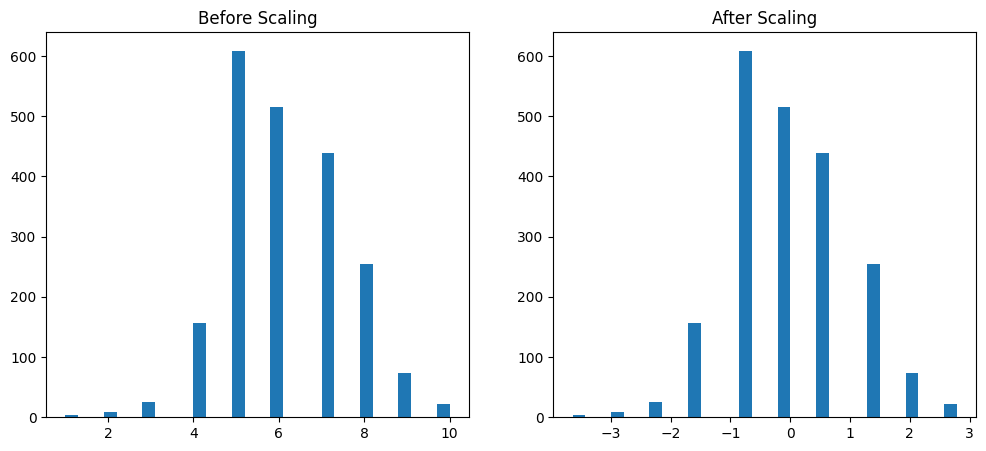

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

axes[0].hist(features_train_simple["Overall Qual"], bins=30)
axes[0].set_title("Before Scaling")

axes[1].hist(features_train_scaled_df["Overall Qual"], bins=30)
axes[1].set_title("After Scaling")

plt.show()

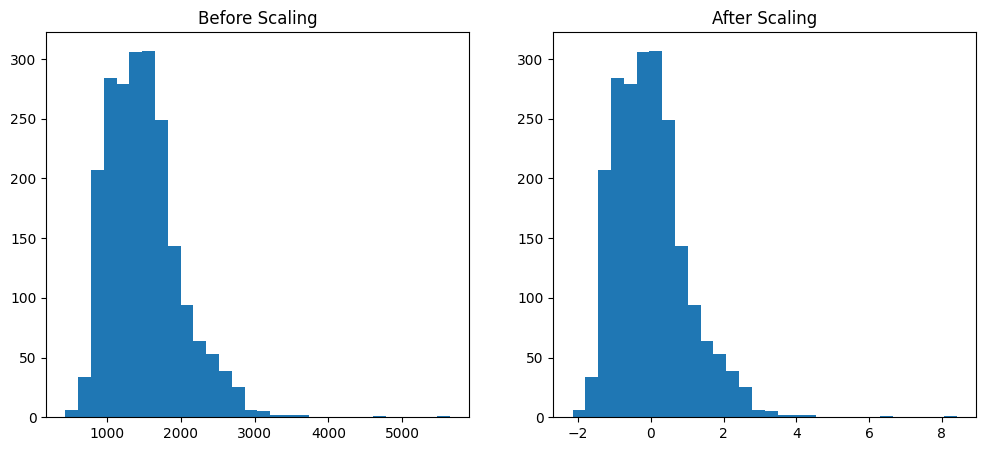

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

axes[0].hist(features_train_simple["Gr Liv Area"], bins=30)
axes[0].set_title("Before Scaling")

axes[1].hist(features_train_scaled_df["Gr Liv Area"], bins=30)
axes[1].set_title("After Scaling")

plt.show()

### Ridge Regression

In [50]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(features_train_scaled, target_train)

ridge_predictions = ridge_model.predict(features_test_scaled)

ridge_rmspe = rmspe(target_test, ridge_predictions)

print(f"Ridge RMSPE: {ridge_rmspe * 100:.2f}%")

Ridge RMSPE: 20.94%


### Lasso Regression

In [51]:
lasso_model = Lasso(alpha=1.0, max_iter=10000)
lasso_model.fit(features_train_scaled, target_train)

lasso_predictions = lasso_model.predict(features_test_scaled)

lasso_rmspe = rmspe(target_test, lasso_predictions)

print(f"Lasso RMSPE: {lasso_rmspe * 100:.2f}%")

Lasso RMSPE: 20.94%


### Compare RMSPE Results

In [52]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge", "Lasso"],
    "RMSPE (%)": [
        simple_linear_rmspe * 100,
        ridge_rmspe * 100,
        lasso_rmspe * 100
    ]
})

results

,Model,RMSPE (%)
0,Linear Regression,20.940924
1,Ridge,20.935198
2,Lasso,20.941024


## Data Visualization


### RMSPE Model Comparison
All three models produced nearly identical RMSPE scores around 21%. Ridge was slightly lower, but the difference was very small. This suggests regularization did not meaningfully improve prediction performance.

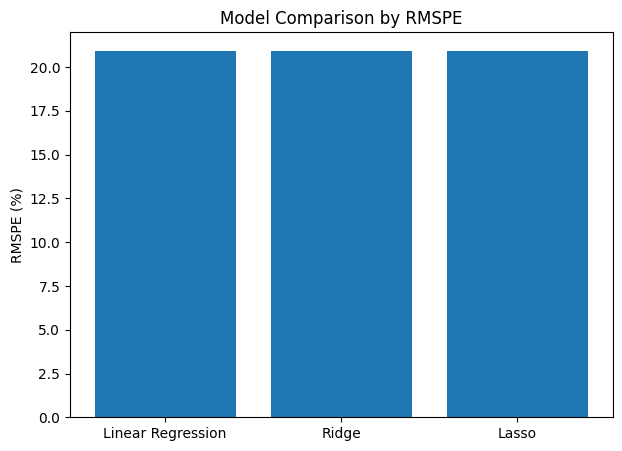

In [53]:
plt.figure(figsize=(7, 5))

plt.bar(results["Model"], results["RMSPE (%)"])

plt.ylabel("RMSPE (%)")
plt.title("Model Comparison by RMSPE")

plt.show()

### Residual Plot

The residual plot shows prediction errors. Ideally, residuals should be randomly scattered around zero. Here, the model performs better for lower and mid-range homes, but struggles more with higher-priced homes.


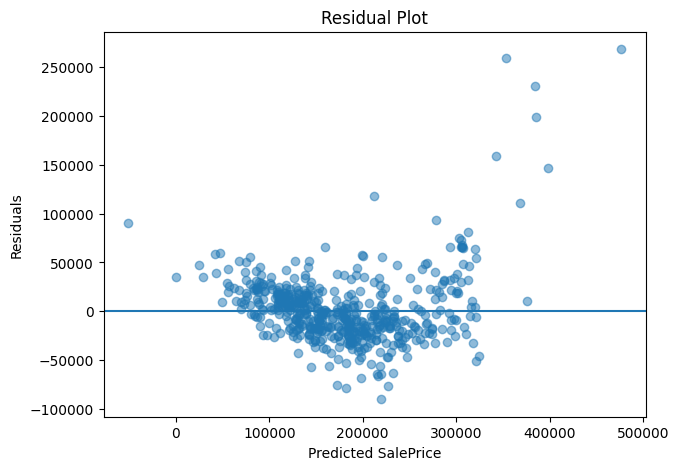

In [54]:
residuals = target_test - predictions

plt.figure(figsize=(7, 5))

plt.scatter(predictions, residuals, alpha=0.5)
plt.axhline(0)

plt.xlabel("Predicted SalePrice")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

### Feature coefficient chart

The coefficient chart shows how each feature contributes to the model’s predicted sale price. Larger positive coefficients increase predicted price more strongly, while smaller or negative coefficients contribute less.


In [57]:
print(len(features_train_simple.columns))
print(len(model2.coef_))

9
5


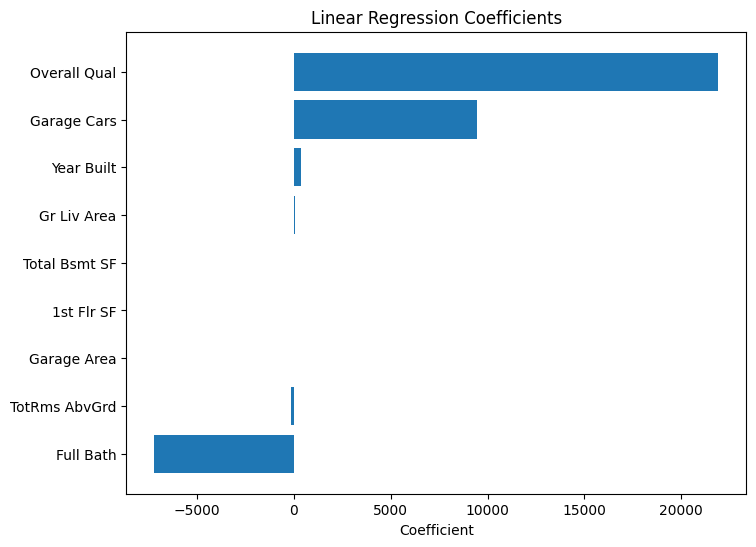

In [58]:
coef_df = pd.DataFrame({
    "Feature": features_train_simple.columns,
    "Coefficient": model1.coef_
}).sort_values("Coefficient", ascending=True)

plt.figure(figsize=(8,6))

plt.barh(coef_df["Feature"], coef_df["Coefficient"])

plt.xlabel("Coefficient")
plt.title("Linear Regression Coefficients")

plt.show()

Scaling placed all features on a common standard deviation scale, making coefficient comparisons more meaningful. Even after scaling, some coefficients remained much larger, indicating that those variables carried genuinely stronger predictive signal rather than simply reflecting larger raw units.

## Final Conclusion

This project used linear regression to predict housing prices in Ames, Iowa. SalePrice was treated as the final signal, while housing features acted like individual tracks contributing to the mix.

The final models produced nearly identical RMSPE scores:

- Linear Regression: about 20.941%
- Ridge: about 20.935%
- Lasso: about 20.941%

Because Ridge and Lasso did not meaningfully improve the score, the simpler linear regression model was nearly as effective as the regularized models.

The Actual vs Predicted plot showed that the model captured the general direction of housing prices, especially for lower and mid-range homes. However, it struggled more with higher-priced homes, where predictions tended to fall below the perfect prediction line.

The residual plot also showed that errors were not perfectly random, especially at higher predicted prices. This suggests the model is useful, but not complete.

Overall, the selected numerical features captured meaningful housing price signal, but the model still missed some important information.

Future improvements could include:
- encoding categorical variables to add more housing information
- stronger feature engineering to capture patterns not visible in the basic numerical features
- tuning Ridge and Lasso alpha values to test whether regularization can improve RMSPE

In the sound engineering analogy: the model found the main tracks in the mix, but some high-end frequencies were still missing. The signal was clear enough to hear, but not fully mastered.